In [1]:
import os
import anndata as ad
import pandas as pd


In [ ]:
# Define the list of CSV file names
csv_names = [
    "mz_metrics_Young_Control_1-1.csv",
    "mz_metrics_Young_Control_1-2.csv",
    "mz_metrics_Young_Control_1-3.csv",
    "mz_metrics_Young_Control_1-4.csv",
    "mz_metrics_Young_Control_1-5.csv",
    "mz_metrics_Young_Control_1-6.csv",
    "mz_metrics_Aged_Control_2-1.csv",
    "mz_metrics_Aged_Control_2-2.csv",
    "mz_metrics_Aged_Control_2-3.csv",
    "mz_metrics_Aged_Control_2-4.csv",
    "mz_metrics_Aged_Control_2-5.csv",
    "mz_metrics_Aged_Control_2-6.csv",
    "mz_metrics_Young_AD_3-3.csv",
    "mz_metrics_Young_AD_3-4.csv",
    "mz_metrics_Young_AD_3-5.csv",
    "mz_metrics_Young_AD_3-6.csv",
    "mz_metrics_Aged_AD_4-1.csv",
    "mz_metrics_Aged_AD_4-2.csv",
    "mz_metrics_Aged_AD_4-3.csv",
    "mz_metrics_Aged_AD_4-4.csv",
    "mz_metrics_Aged_AD_4-5.csv",
    "mz_metrics_Aged_AD_4-6.csv"
]

# Corresponding sample names
sample_names = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
                'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
                'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
                'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']

# Create an empty DataFrame
df = pd.DataFrame()

# Loop through each file and corresponding sample name
for i, (csv, sample_name) in enumerate(zip(csv_names, sample_names)):
    input_file = f"/mz_metric_folder_address/{csv}"
    
    if not os.path.exists(input_file):
        print(f"File not found: {input_file}")
        continue

    print(f"Loading CSV from: {input_file}")
    csv_df = pd.read_csv(input_file)
    
    # Add zero-filled sample columns if they don't exist
    for sn in sample_names:
        if sn not in csv_df.columns:
            csv_df[sn] = 0

    # Set the current sample's column to 1
    csv_df[sample_name] = 1

    # Append to the master DataFrame
    df = pd.concat([df, csv_df], ignore_index=True)

Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-1.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-2.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-3.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-4.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-5.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Young_Control_1-6.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Aged_Control_2-1.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML Tools/lipid dispersion paper/results/mz_metrics_Aged_Control_2-2.csv
Loading CSV from: /home/ajarrah/PhD_Thesis/IMZML T

In [3]:
df

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,YC_1,YC_2,...,YAD_1,YAD_2,YAD_3,YAD_4,AAD_1,AAD_2,AAD_3,AAD_4,AAD_5,AAD_6
0,136.0644,0.082302,173,0.064794,7.883047,0.414949,0.002087,0.000035,1,0,...,0,0,0,0,0,0,0,0,0,0
1,147.1182,0.148929,347,0.129963,9.447973,0.509292,0.000606,0.000019,1,0,...,0,0,0,0,0,0,0,0,0,0
2,152.0577,0.034094,66,0.024719,4.520112,0.212212,0.001192,0.000011,1,0,...,0,0,0,0,0,0,0,0,0,0
3,161.1321,0.312176,801,0.300000,10.015900,0.543530,0.000857,0.000049,1,0,...,0,0,0,0,0,0,0,0,0,0
4,175.1472,0.062050,120,0.044944,7.420507,0.387065,0.000608,0.000008,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,1543.1592,0.089526,688,0.083096,4.383649,0.211698,0.000316,0.000024,0,0,...,0,0,0,0,0,0,0,0,0,1
8064,1544.1542,0.121903,903,0.113740,5.256047,0.276999,0.000373,0.000031,0,0,...,0,0,0,0,0,0,0,0,0,1
8065,1545.1667,0.090490,685,0.082668,4.749866,0.239110,0.000259,0.000020,0,0,...,0,0,0,0,0,0,0,0,0,1
8066,1548.1890,0.094625,721,0.087799,4.552116,0.224308,0.000265,0.000021,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
# Define intensity columns
intensity_columns = ["mean_intensity_tissue", "mean_intensity_bg"]

# Use your actual sample column names
sample_columns = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
                  'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
                  'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
                  'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']

# Only keep sample columns that actually exist in the DataFrame
sample_columns = [col for col in sample_columns if col in df.columns]

# Create normalized versions of intensity columns
normalized_columns = {}
for col in intensity_columns:
    min_val = df[col].min()
    max_val = df[col].max()
    norm_col = f"normalized_{col}"
    if max_val > min_val:
        normalized_columns[norm_col] = (df[col] - min_val) / (max_val - min_val)
    else:
        normalized_columns[norm_col] = 0.0  # Or np.zeros(len(df))

# Insert normalized columns just before the first sample column
if sample_columns:
    first_sample_index = df.columns.get_loc(sample_columns[0])
else:
    raise ValueError("No valid sample columns found in the DataFrame.")

# Insert the normalized columns in reverse order to maintain order when using `.insert`
for norm_col, norm_values in reversed(normalized_columns.items()):
    df.insert(first_sample_index, norm_col, norm_values)

In [ ]:

epsilon = 1e-8  # or a small number appropriate for your data

df["mean_intensity_tissue_log"] = np.log(df["mean_intensity_tissue"] + epsilon)
df["mean_intensity_bg_log"] = np.log(df["mean_intensity_bg"] + epsilon)

# Now normalize the log-transformed values
for col in ["mean_intensity_tissue_log", "mean_intensity_bg_log"]:
    min_val = df[col].min()
    max_val = df[col].max()
    df[f"normalized_{col}"] = (df[col] - min_val) / (max_val - min_val)

In [6]:
df

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_1,AAD_2,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log
0,136.0644,0.082302,173,0.064794,7.883047,0.414949,0.002087,0.000035,0.033260,0.002405,...,0,0,0,0,0,0,-6.171997,-10.256272,0.472096,0.575192
1,147.1182,0.148929,347,0.129963,9.447973,0.509292,0.000606,0.000019,0.008415,0.001329,...,0,0,0,0,0,0,-7.409160,-10.849372,0.277375,0.533407
2,152.0577,0.034094,66,0.024719,4.520112,0.212212,0.001192,0.000011,0.018248,0.000772,...,0,0,0,0,0,0,-6.732127,-11.391860,0.383935,0.495188
3,161.1321,0.312176,801,0.300000,10.015900,0.543530,0.000857,0.000049,0.012626,0.003362,...,0,0,0,0,0,0,-7.062322,-9.921430,0.331965,0.598782
4,175.1472,0.062050,120,0.044944,7.420507,0.387065,0.000608,0.000008,0.008449,0.000560,...,0,0,0,0,0,0,-7.405824,-11.712671,0.277900,0.472587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,1543.1592,0.089526,688,0.083096,4.383649,0.211698,0.000316,0.000024,0.003549,0.001629,...,0,0,0,0,0,1,-8.061207,-10.646056,0.174747,0.547731
8064,1544.1542,0.121903,903,0.113740,5.256047,0.276999,0.000373,0.000031,0.004505,0.002151,...,0,0,0,0,0,1,-7.895109,-10.368053,0.200889,0.567317
8065,1545.1667,0.090490,685,0.082668,4.749866,0.239110,0.000259,0.000020,0.002602,0.001386,...,0,0,0,0,0,1,-8.258344,-10.807096,0.143719,0.536385
8066,1548.1890,0.094625,721,0.087799,4.552116,0.224308,0.000265,0.000021,0.002709,0.001437,...,0,0,0,0,0,1,-8.234052,-10.771321,0.147542,0.538906


In [7]:
df["mz"] = df["mz"].astype(float).round(2)
df

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_1,AAD_2,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log
0,136.06,0.082302,173,0.064794,7.883047,0.414949,0.002087,0.000035,0.033260,0.002405,...,0,0,0,0,0,0,-6.171997,-10.256272,0.472096,0.575192
1,147.12,0.148929,347,0.129963,9.447973,0.509292,0.000606,0.000019,0.008415,0.001329,...,0,0,0,0,0,0,-7.409160,-10.849372,0.277375,0.533407
2,152.06,0.034094,66,0.024719,4.520112,0.212212,0.001192,0.000011,0.018248,0.000772,...,0,0,0,0,0,0,-6.732127,-11.391860,0.383935,0.495188
3,161.13,0.312176,801,0.300000,10.015900,0.543530,0.000857,0.000049,0.012626,0.003362,...,0,0,0,0,0,0,-7.062322,-9.921430,0.331965,0.598782
4,175.15,0.062050,120,0.044944,7.420507,0.387065,0.000608,0.000008,0.008449,0.000560,...,0,0,0,0,0,0,-7.405824,-11.712671,0.277900,0.472587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,1543.16,0.089526,688,0.083096,4.383649,0.211698,0.000316,0.000024,0.003549,0.001629,...,0,0,0,0,0,1,-8.061207,-10.646056,0.174747,0.547731
8064,1544.15,0.121903,903,0.113740,5.256047,0.276999,0.000373,0.000031,0.004505,0.002151,...,0,0,0,0,0,1,-7.895109,-10.368053,0.200889,0.567317
8065,1545.17,0.090490,685,0.082668,4.749866,0.239110,0.000259,0.000020,0.002602,0.001386,...,0,0,0,0,0,1,-8.258344,-10.807096,0.143719,0.536385
8066,1548.19,0.094625,721,0.087799,4.552116,0.224308,0.000265,0.000021,0.002709,0.001437,...,0,0,0,0,0,1,-8.234052,-10.771321,0.147542,0.538906


In [8]:
# Sort mz for logical grouping
df = df.sort_values("mz").reset_index(drop=True)

# Initialize
groups = []
used = set()
group_id = 0

for i, mz in enumerate(df["mz"]):
    if i in used:
        continue
    # Start new group
    group = [i]
    used.add(i)
    current_members = [mz]

    # Expand group transitively
    j = 0
    while j < len(group):
        index = group[j]
        mz_j = df.loc[index, "mz"]
        for k in range(len(df)):
            if k in used:
                continue
            mz_k = df.loc[k, "mz"]
            if any(abs(mz_k - m) <= 0.01 for m in current_members):
                group.append(k)
                used.add(k)
                current_members.append(mz_k)
        j += 1

    # Assign group_id to all group members
    for idx in group:
        df.loc[idx, "group_id"] = group_id
    group_id += 1

# Make sure group_id is integer
df["group_id"] = df["group_id"].astype(int)

df

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_2,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log,group_id
0,104.11,0.146765,492,0.130761,6.017918,0.450842,0.000704,0.000022,0.010071,0.001509,...,0,0,0,0,0,-7.258132,-10.722396,0.301145,0.542353,0
1,104.11,0.135174,501,0.121625,6.028357,0.392609,0.000613,0.000030,0.008533,0.002039,...,0,0,0,0,0,-7.397595,-10.421501,0.279195,0.563551,0
2,104.11,0.107907,425,0.086407,6.531191,0.516410,0.000843,0.000029,0.012392,0.001999,...,0,0,0,0,0,-7.078742,-10.441098,0.329380,0.562170,0
3,104.11,0.271983,1616,0.261481,7.893198,0.471521,0.000705,0.000074,0.010084,0.005101,...,0,0,0,0,0,-7.256974,-9.504667,0.301328,0.628143,0
4,129.14,0.160524,732,0.151106,4.661398,0.339452,0.000828,0.000046,0.012139,0.003175,...,0,0,0,0,0,-7.096820,-9.978581,0.326535,0.594755,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,1571.19,0.044394,122,0.024203,7.956408,0.428015,0.000228,0.000003,0.002081,0.000185,...,0,0,0,0,0,-8.385985,-12.816086,0.123629,0.394850,699
8064,1571.19,0.135158,479,0.116273,7.272940,0.493959,0.000201,0.000011,0.001627,0.000719,...,0,0,0,0,0,-8.512205,-11.462797,0.103763,0.490191,699
8065,1571.19,0.111163,261,0.112747,2.115210,0.081062,0.000220,0.000011,0.001954,0.000747,...,0,0,0,0,0,-8.419684,-11.425545,0.118325,0.492815,699
8066,1571.19,0.136311,403,0.133576,3.088365,0.188260,0.000257,0.000011,0.002559,0.000734,...,0,0,0,0,0,-8.268240,-11.442453,0.142161,0.491624,699


In [9]:
df.head(40)

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_2,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log,group_id
0,104.11,0.146765,492,0.130761,6.017918,0.450842,0.000704,0.000022,0.010071,0.001509,...,0,0,0,0,0,-7.258132,-10.722396,0.301145,0.542353,0
1,104.11,0.135174,501,0.121625,6.028357,0.392609,0.000613,0.000030,0.008533,0.002039,...,0,0,0,0,0,-7.397595,-10.421501,0.279195,0.563551,0
2,104.11,0.107907,425,0.086407,6.531191,0.516410,0.000843,0.000029,0.012392,0.001999,...,0,0,0,0,0,-7.078742,-10.441098,0.329380,0.562170,0
3,104.11,0.271983,1616,0.261481,7.893198,0.471521,0.000705,0.000074,0.010084,0.005101,...,0,0,0,0,0,-7.256974,-9.504667,0.301328,0.628143,0
4,129.14,0.160524,732,0.151106,4.661398,0.339452,0.000828,0.000046,0.012139,0.003175,...,0,0,0,0,0,-7.096820,-9.978581,0.326535,0.594755,1
5,129.14,0.284325,1732,0.282429,5.261332,0.320352,0.000980,0.000146,0.014692,0.010017,...,0,0,1,0,0,-6.928003,-8.829864,0.353106,0.675684,1
6,129.14,0.458064,2616,0.460278,7.010214,0.415996,0.000895,0.000193,0.013273,0.013197,...,1,0,0,0,0,-7.018306,-8.554176,0.338893,0.695106,1
7,129.14,0.231319,856,0.228296,4.213910,0.288758,0.000784,0.000049,0.011410,0.003352,...,0,0,0,0,0,-7.150792,-9.924366,0.318040,0.598575,1
8,129.14,0.220349,1221,0.214053,6.189903,0.339960,0.000774,0.000072,0.011240,0.004918,...,0,0,0,0,0,-7.163734,-9.541186,0.316003,0.625570,1
9,129.14,0.153447,749,0.150666,4.352977,0.206303,0.000772,0.000058,0.011212,0.003969,...,0,0,0,0,0,-7.165896,-9.755428,0.315663,0.610477,1


In [10]:
import pandas as pd

# Explicit sample column names based on your data
sample_cols = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
               'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
               'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
               'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']

# Keep only columns that are present in the DataFrame
sample_cols = [col for col in sample_cols if col in df.columns]

# Count how many samples contributed to each row
df["n_samples"] = df[sample_cols].sum(axis=1)

# Group and aggregate
summary = df.groupby("group_id").agg({
    "mz": "first",  # assuming mz is consistent within group
    "n_samples": "sum",
    "dispersion_score": ["mean", "std"],
    "bg_nonzero_area": ["mean", "std"],
    "normalized_bg_nonzero_area": ["mean", "std"],
    "bg_dist_mean": ["mean", "std"],
    "normalized_bg_dist_mean": ["mean", "std"],
    "mean_intensity_tissue": ["mean", "std"],
    "normalized_mean_intensity_tissue": ["mean", "std"],
    "mean_intensity_bg": ["mean", "std"],
    "normalized_mean_intensity_bg": ["mean", "std"],
    "mean_intensity_tissue_log": ["mean", "std"],
    "mean_intensity_bg_log": ["mean", "std"],
    "normalized_mean_intensity_tissue_log": ["mean", "std"],
    "normalized_mean_intensity_bg_log": ["mean", "std"]
}).reset_index()

# Flatten MultiIndex columns
summary.columns = ['group_id', 'mz', 'n_samples',
                   'dispersion_mean', 'dispersion_std',
                   'bg_area_mean', 'bg_area_std',
                   'norm_bg_area_mean', 'norm_bg_area_std',
                   'bg_dist_mean', 'bg_dist_std',
                   'norm_bg_dist_mean', 'norm_bg_dist_std',
                   'mean_intensity_tissue_mean', 'mean_intensity_tissue_std',
                   'norm_mean_intensity_tissue_mean', 'norm_mean_intensity_tissue_std',
                   'mean_intensity_bg_mean', 'mean_intensity_bg_std',
                   'norm_mean_intensity_bg_mean', 'norm_mean_intensity_bg_std',
                   'mean_intensity_tissue_log_mean', 'mean_intensity_tissue_log_std',
                   'mean_intensity_bg_log_mean', 'mean_intensity_bg_log_std',
                   'norm_mean_intensity_tissue_log_mean', 'norm_mean_intensity_tissue_log_std',
                   'norm_mean_intensity_bg_log_mean', 'norm_mean_intensity_bg_log_std']

# Display summary
summary


,group_id,mz,n_samples,dispersion_mean,dispersion_std,bg_area_mean,bg_area_std,norm_bg_area_mean,norm_bg_area_std,bg_dist_mean,...,norm_mean_intensity_bg_mean,norm_mean_intensity_bg_std,mean_intensity_tissue_log_mean,mean_intensity_tissue_log_std,mean_intensity_bg_log_mean,mean_intensity_bg_log_std,norm_mean_intensity_tissue_log_mean,norm_mean_intensity_tissue_log_std,norm_mean_intensity_bg_log_mean,norm_mean_intensity_bg_log_std
0,0,104.11,4,0.165457,0.072861,758.500000,572.671226,0.150068,0.076697,6.617666,...,0.002662,0.001644,-7.247861,0.130653,-10.272416,0.529969,0.302762,0.020564,0.574054,0.037337
1,1,129.14,13,0.255466,0.108287,1167.076923,764.312377,0.253257,0.111083,4.677102,...,0.006238,0.003757,-7.082844,0.090393,-9.472760,0.615828,0.328735,0.014227,0.630391,0.043386
2,2,136.06,17,0.304461,0.157054,1392.411765,857.404008,0.297980,0.157923,6.673292,...,0.010171,0.006393,-6.546783,0.540486,-9.016809,0.707938,0.413107,0.085069,0.662513,0.049875
3,3,147.12,5,0.129776,0.075131,326.800000,228.310534,0.108668,0.073211,7.855965,...,0.001214,0.000648,-7.245110,0.123488,-11.065468,0.573914,0.303195,0.019436,0.518183,0.040433
4,4,152.06,6,0.112799,0.097894,347.833333,323.375581,0.110311,0.100974,3.154255,...,0.004625,0.005552,-6.798669,0.125472,-10.110692,1.086342,0.373462,0.019748,0.585448,0.076534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,695,1560.15,4,0.044822,0.021917,120.750000,48.828782,0.040624,0.025277,2.576501,...,0.000276,0.000128,-8.164676,0.097596,-12.512861,0.523354,0.158461,0.015361,0.416212,0.036871
696,696,1561.15,1,0.023198,NaN,82.000000,NaN,0.020583,NaN,1.848690,...,0.000196,NaN,-8.355771,NaN,-12.759698,NaN,0.128384,NaN,0.398822,NaN
697,697,1568.16,1,0.060884,NaN,190.000000,NaN,0.054782,NaN,2.960837,...,0.000487,NaN,-8.530871,NaN,-11.851980,NaN,0.100825,NaN,0.462772,NaN
698,698,1570.17,13,0.086774,0.030332,385.384615,183.461412,0.079547,0.033671,4.251671,...,0.000806,0.000365,-8.207977,0.093923,-11.448351,0.478404,0.151646,0.014783,0.491208,0.033704


In [11]:
# Define your expected sample columns exactly as given
sample_cols = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
               'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
               'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
               'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']

# Check which sample columns are actually present in your DataFrame
existing_sample_cols = [col for col in sample_cols if col in df.columns]

# Check if 'mz' and 'dispersion_score' exist in the DataFrame
id_vars = []
for col in ['mz', 'dispersion_score']:
    if col in df.columns:
        id_vars.append(col)
    else:
        print(f"Missing id_var: {col}")

# Print any sample columns that are missing
missing_cols = [col for col in sample_cols if col not in df.columns]
if missing_cols:
    print("⚠️ Missing sample columns:", missing_cols)

# Proceed only with existing columns
df_long = df.melt(id_vars=id_vars, value_vars=existing_sample_cols,
                  var_name='sample', value_name='present')

# Filter only the rows where the sample has that m/z
df_present = df_long[df_long['present'] == 1]

# Create the final dispersion matrix
dispersion_by_sample = df_present.pivot_table(
    index='mz',
    columns='sample',
    values='dispersion_score',
    aggfunc='mean'
)

In [12]:
filtered_summary = summary[summary['n_samples'] > 21]
filtered_summary.head(2000)

,group_id,mz,n_samples,dispersion_mean,dispersion_std,bg_area_mean,bg_area_std,norm_bg_area_mean,norm_bg_area_std,bg_dist_mean,...,norm_mean_intensity_bg_mean,norm_mean_intensity_bg_std,mean_intensity_tissue_log_mean,mean_intensity_tissue_log_std,mean_intensity_bg_log_mean,mean_intensity_bg_log_std,norm_mean_intensity_tissue_log_mean,norm_mean_intensity_tissue_log_std,norm_mean_intensity_bg_log_mean,norm_mean_intensity_bg_log_std
19,19,201.93,22,0.107190,0.066824,495.727273,357.567068,0.102076,0.066486,3.820454,...,0.004542,0.003689,-6.332389,0.160079,-10.062723,1.150679,0.446851,0.025195,0.588827,0.081067
33,33,222.08,22,0.199269,0.127976,955.681818,807.487838,0.187485,0.125599,6.498083,...,0.003729,0.002908,-7.014906,0.187385,-10.198464,1.034347,0.339428,0.029493,0.579264,0.072871
35,35,224.10,22,0.230522,0.159512,1192.500000,1108.200504,0.226057,0.159110,5.142203,...,0.009306,0.008175,-6.147285,0.121059,-9.387179,1.185383,0.475986,0.019054,0.636420,0.083512
45,45,240.09,22,0.303596,0.187388,1515.045455,1225.156568,0.300266,0.188202,5.751372,...,0.015076,0.012248,-5.903572,0.143421,-8.892899,1.190120,0.514345,0.022574,0.671243,0.083845
65,65,264.27,22,0.103901,0.044977,449.727273,327.773903,0.093253,0.043471,5.031391,...,0.004359,0.003179,-6.258041,0.167532,-9.898681,0.708315,0.458553,0.026368,0.600384,0.049902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,605,896.47,22,0.093747,0.071609,410.045455,334.705340,0.088393,0.071502,3.710141,...,0.001160,0.000937,-7.557026,0.134517,-11.367969,0.979355,0.254102,0.021172,0.496871,0.068997
608,608,912.45,22,0.048159,0.035199,218.681818,164.924914,0.045799,0.036467,2.456736,...,0.000973,0.000835,-6.994886,0.199996,-11.558189,0.986118,0.342579,0.031478,0.483470,0.069473
613,613,925.52,22,0.108318,0.076303,491.409091,419.583201,0.102386,0.076738,4.049223,...,0.001067,0.000871,-7.757549,0.105721,-11.423198,0.933657,0.222541,0.016640,0.492980,0.065777
631,631,948.53,22,0.135453,0.080910,629.454545,457.407157,0.128797,0.080853,4.550594,...,0.001822,0.001295,-7.425241,0.098563,-10.874807,0.958396,0.274844,0.015513,0.531615,0.067520


In [13]:
df_filtered = df[df['group_id'].isin(filtered_summary['group_id'])]
df_filtered.head(2000)

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log,group_id,n_samples
120,201.93,0.116344,342,0.113358,2.919943,0.173078,0.001736,0.000047,0.027373,0.003222,...,0,0,0,0,-6.356157,-9.963896,0.443111,0.595790,19,1
121,201.93,0.081365,459,0.072397,4.688044,0.251758,0.001538,0.000039,0.024060,0.002663,...,0,0,0,0,-6.476944,-10.154412,0.424099,0.582368,19,1
122,201.93,0.144763,811,0.139993,4.811063,0.235393,0.001321,0.000075,0.020410,0.005133,...,0,0,0,0,-6.629463,-9.498418,0.400094,0.628583,19,1
123,201.93,0.069008,250,0.065916,2.421833,0.127747,0.001582,0.000024,0.024791,0.001642,...,0,0,0,0,-6.448992,-10.637916,0.428499,0.548304,19,1
124,201.93,0.168487,827,0.166398,4.383444,0.208177,0.001378,0.000095,0.021367,0.006493,...,0,0,0,0,-6.587176,-9.263425,0.406750,0.645139,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5219,801.56,0.063357,253,0.061299,2.465272,0.102456,0.002143,0.000030,0.034204,0.002069,...,0,0,0,0,-6.145406,-10.406769,0.476282,0.564589,467,1
5220,801.56,0.062888,180,0.057043,4.075077,0.173940,0.001591,0.000017,0.024939,0.001154,...,0,0,0,0,-6.443460,-10.990485,0.429370,0.523466,467,1
5221,801.56,0.093320,531,0.089415,3.916201,0.167529,0.001626,0.000041,0.025520,0.002798,...,0,0,0,0,-6.421906,-10.105131,0.432762,0.585840,467,1
5222,801.56,0.023535,65,0.020454,2.171016,0.082069,0.002366,0.000008,0.037943,0.000556,...,0,0,0,0,-6.046436,-11.719979,0.491859,0.472072,467,1


In [14]:
df_filtered.tail(20)

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log,group_id,n_samples
7660,974.54,0.072379,387,0.067641,3.591087,0.162387,0.000780,0.000023,0.011344,0.001608,...,0,0,0,0,-7.155810,-10.658835,0.317250,0.546831,649,1
7661,974.54,0.138829,611,0.125606,5.196118,0.390058,0.000649,0.000024,0.009142,0.001667,...,0,0,0,0,-7.340053,-10.622615,0.288252,0.549382,649,1
7662,974.54,0.199938,740,0.204476,2.177329,0.113729,0.000784,0.000051,0.011405,0.003461,...,0,0,0,0,-7.151108,-9.892511,0.317990,0.600819,649,1
7663,974.54,0.137690,733,0.126932,6.834449,0.342098,0.000644,0.000025,0.009051,0.001681,...,0,0,0,0,-7.348421,-10.614268,0.286935,0.549970,649,1
7664,974.55,0.111072,514,0.103267,5.215120,0.259349,0.000689,0.000019,0.009813,0.001281,...,0,0,0,0,-7.280190,-10.885738,0.297674,0.530845,649,1
7665,974.55,0.043525,68,0.025468,7.412772,0.386598,0.000755,0.000004,0.010917,0.000305,...,0,0,0,0,-7.188930,-12.319886,0.312038,0.429808,649,1
7666,974.55,0.061266,211,0.061431,1.690880,0.058132,0.000753,0.000020,0.010890,0.001363,...,0,0,0,0,-7.191107,-10.824035,0.311695,0.535192,649,1
7667,974.55,0.049595,140,0.044061,2.094801,0.154730,0.000647,0.000009,0.009114,0.000648,...,0,0,0,0,-7.342628,-11.566763,0.287846,0.482866,649,1
7668,974.55,0.035863,112,0.032156,2.868055,0.106290,0.000679,0.000005,0.009646,0.000344,...,0,0,0,0,-7.294750,-12.199965,0.295382,0.438256,649,1
7669,974.55,0.105483,321,0.101976,4.054214,0.172112,0.000511,0.000011,0.006833,0.000767,...,0,0,0,0,-7.578399,-11.398346,0.250738,0.494731,649,1


In [15]:
sample_cols = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
               'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
               'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
               'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']
# Melt the DataFrame to long format
df_filtered_long = df_filtered.melt(id_vars=['mz', 'dispersion_score'], value_vars=sample_cols,
                  var_name='sample', value_name='present')

# Filter only the rows where the sample has that m/z
df_filtered_present = df_filtered_long[df_long['present'] == 1]

# Now pivot to get m/z x sample matrix of dispersion scores
dispersion_by_sample_filtered = df_filtered_present.pivot_table(index='mz', columns='sample', values='dispersion_score', aggfunc='mean')

/tmp/ipykernel_3320605/2916609763.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered_present = df_filtered_long[df_long['present'] == 1]


In [16]:
top_dispersion_filtered = filtered_summary.sort_values(by='dispersion_mean', ascending=False).head(20)
top_dispersion_filtered.head(20)


,group_id,mz,n_samples,dispersion_mean,dispersion_std,bg_area_mean,bg_area_std,norm_bg_area_mean,norm_bg_area_std,bg_dist_mean,...,norm_mean_intensity_bg_mean,norm_mean_intensity_bg_std,mean_intensity_tissue_log_mean,mean_intensity_tissue_log_std,mean_intensity_bg_log_mean,mean_intensity_bg_log_std,norm_mean_intensity_tissue_log_mean,norm_mean_intensity_tissue_log_std,norm_mean_intensity_bg_log_mean,norm_mean_intensity_bg_log_std
128,128,370.35,22,0.684323,0.224306,2999.909091,1434.638760,0.681184,0.230439,10.396902,...,0.109479,0.056962,-4.361079,0.110541,-6.552497,0.485000,0.757123,0.017398,0.836127,0.034169
126,126,369.35,22,0.665425,0.246725,2877.181818,1418.842272,0.661850,0.253285,10.238157,...,0.413088,0.225461,-3.009101,0.117790,-5.239200,0.525126,0.969916,0.018539,0.928650,0.036996
123,123,367.33,22,0.569226,0.197751,2628.272727,1566.718475,0.561431,0.200655,10.073611,...,0.053952,0.034108,-4.957835,0.110887,-7.300889,0.543633,0.663197,0.017453,0.783402,0.038300
316,316,651.53,22,0.504074,0.237521,2290.136364,1478.061836,0.509002,0.242279,6.320232,...,0.052255,0.031561,-4.990048,0.138239,-7.321568,0.536029,0.658127,0.021758,0.781945,0.037764
317,317,652.54,22,0.468835,0.210980,2134.227273,1322.897323,0.471726,0.215061,6.352531,...,0.023498,0.014288,-5.779362,0.129254,-8.131052,0.562565,0.533894,0.020344,0.724916,0.039633
130,130,371.35,22,0.387918,0.161911,1810.045455,1344.781217,0.373976,0.163699,9.282568,...,0.010965,0.007680,-6.363624,0.119235,-8.927682,0.597920,0.441935,0.018767,0.668792,0.042124
298,298,627.53,22,0.386630,0.198855,1808.181818,1324.844991,0.388833,0.201344,5.525972,...,0.031646,0.022362,-5.323484,0.141077,-7.884418,0.645750,0.605647,0.022205,0.742291,0.045494
299,299,628.54,22,0.361086,0.183691,1659.636364,1164.105769,0.361280,0.186137,5.635197,...,0.014057,0.009908,-6.124825,0.140514,-8.705883,0.671014,0.479521,0.022116,0.684418,0.047274
403,403,768.55,22,0.356961,0.194479,1670.000000,1209.571353,0.357496,0.197994,5.565281,...,0.014049,0.009529,-6.046650,0.084698,-8.707043,0.694062,0.491825,0.013331,0.684337,0.048897
432,432,784.57,22,0.345211,0.163193,1594.227273,1142.986728,0.337550,0.165806,7.369493,...,0.011095,0.006954,-6.256421,0.077464,-8.920856,0.662630,0.458808,0.012192,0.669273,0.046683


In [17]:
top_dispersion_filtered.tail(20)


,group_id,mz,n_samples,dispersion_mean,dispersion_std,bg_area_mean,bg_area_std,norm_bg_area_mean,norm_bg_area_std,bg_dist_mean,...,norm_mean_intensity_bg_mean,norm_mean_intensity_bg_std,mean_intensity_tissue_log_mean,mean_intensity_tissue_log_std,mean_intensity_bg_log_mean,mean_intensity_bg_log_std,norm_mean_intensity_tissue_log_mean,norm_mean_intensity_tissue_log_std,norm_mean_intensity_bg_log_mean,norm_mean_intensity_bg_log_std
128,128,370.35,22,0.684323,0.224306,2999.909091,1434.638760,0.681184,0.230439,10.396902,...,0.109479,0.056962,-4.361079,0.110541,-6.552497,0.485000,0.757123,0.017398,0.836127,0.034169
126,126,369.35,22,0.665425,0.246725,2877.181818,1418.842272,0.661850,0.253285,10.238157,...,0.413088,0.225461,-3.009101,0.117790,-5.239200,0.525126,0.969916,0.018539,0.928650,0.036996
123,123,367.33,22,0.569226,0.197751,2628.272727,1566.718475,0.561431,0.200655,10.073611,...,0.053952,0.034108,-4.957835,0.110887,-7.300889,0.543633,0.663197,0.017453,0.783402,0.038300
316,316,651.53,22,0.504074,0.237521,2290.136364,1478.061836,0.509002,0.242279,6.320232,...,0.052255,0.031561,-4.990048,0.138239,-7.321568,0.536029,0.658127,0.021758,0.781945,0.037764
317,317,652.54,22,0.468835,0.210980,2134.227273,1322.897323,0.471726,0.215061,6.352531,...,0.023498,0.014288,-5.779362,0.129254,-8.131052,0.562565,0.533894,0.020344,0.724916,0.039633
130,130,371.35,22,0.387918,0.161911,1810.045455,1344.781217,0.373976,0.163699,9.282568,...,0.010965,0.007680,-6.363624,0.119235,-8.927682,0.597920,0.441935,0.018767,0.668792,0.042124
298,298,627.53,22,0.386630,0.198855,1808.181818,1324.844991,0.388833,0.201344,5.525972,...,0.031646,0.022362,-5.323484,0.141077,-7.884418,0.645750,0.605647,0.022205,0.742291,0.045494
299,299,628.54,22,0.361086,0.183691,1659.636364,1164.105769,0.361280,0.186137,5.635197,...,0.014057,0.009908,-6.124825,0.140514,-8.705883,0.671014,0.479521,0.022116,0.684418,0.047274
403,403,768.55,22,0.356961,0.194479,1670.000000,1209.571353,0.357496,0.197994,5.565281,...,0.014049,0.009529,-6.046650,0.084698,-8.707043,0.694062,0.491825,0.013331,0.684337,0.048897
432,432,784.57,22,0.345211,0.163193,1594.227273,1142.986728,0.337550,0.165806,7.369493,...,0.011095,0.006954,-6.256421,0.077464,-8.920856,0.662630,0.458808,0.012192,0.669273,0.046683


In [18]:
group_stats_filtered = df_filtered.groupby(['group_id'])['dispersion_score'].agg(['mean', 'std', 'count']).reset_index()
group_stats_filtered = group_stats_filtered.sort_values(by='mean', ascending=False)  # rank by mean dispersion

In [19]:
top_groups_filtered = group_stats_filtered.head(10)
bottom_groups_filtered = group_stats_filtered.tail(10)
print("Top 5 Groups with Highest Dispersion:\n", top_groups_filtered)
print("Bottom 5 Groups with Lowest Dispersion:\n", bottom_groups_filtered)

Top 5 Groups with Highest Dispersion:
     group_id      mean       std  count
12       128  0.684323  0.224306     22
11       126  0.665425  0.246725     22
10       123  0.569226  0.197751     22
38       316  0.504074  0.237521     22
39       317  0.468835  0.210980     22
13       130  0.387918  0.161911     22
32       298  0.386630  0.198855     22
33       299  0.361086  0.183691     22
63       403  0.356961  0.194479     22
73       432  0.345211  0.163193     22
Bottom 5 Groups with Lowest Dispersion:
      group_id      mean       std  count
47        362  0.019196  0.013999     22
127       563  0.014511  0.010495     22
121       548  0.014340  0.011997     22
135       588  0.014144  0.009687     22
131       571  0.014074  0.011532     22
129       569  0.013697  0.009648     22
120       547  0.013537  0.012934     22
126       560  0.010401  0.008110     22
134       586  0.009305  0.011764     22
133       583  0.007994  0.008863     22


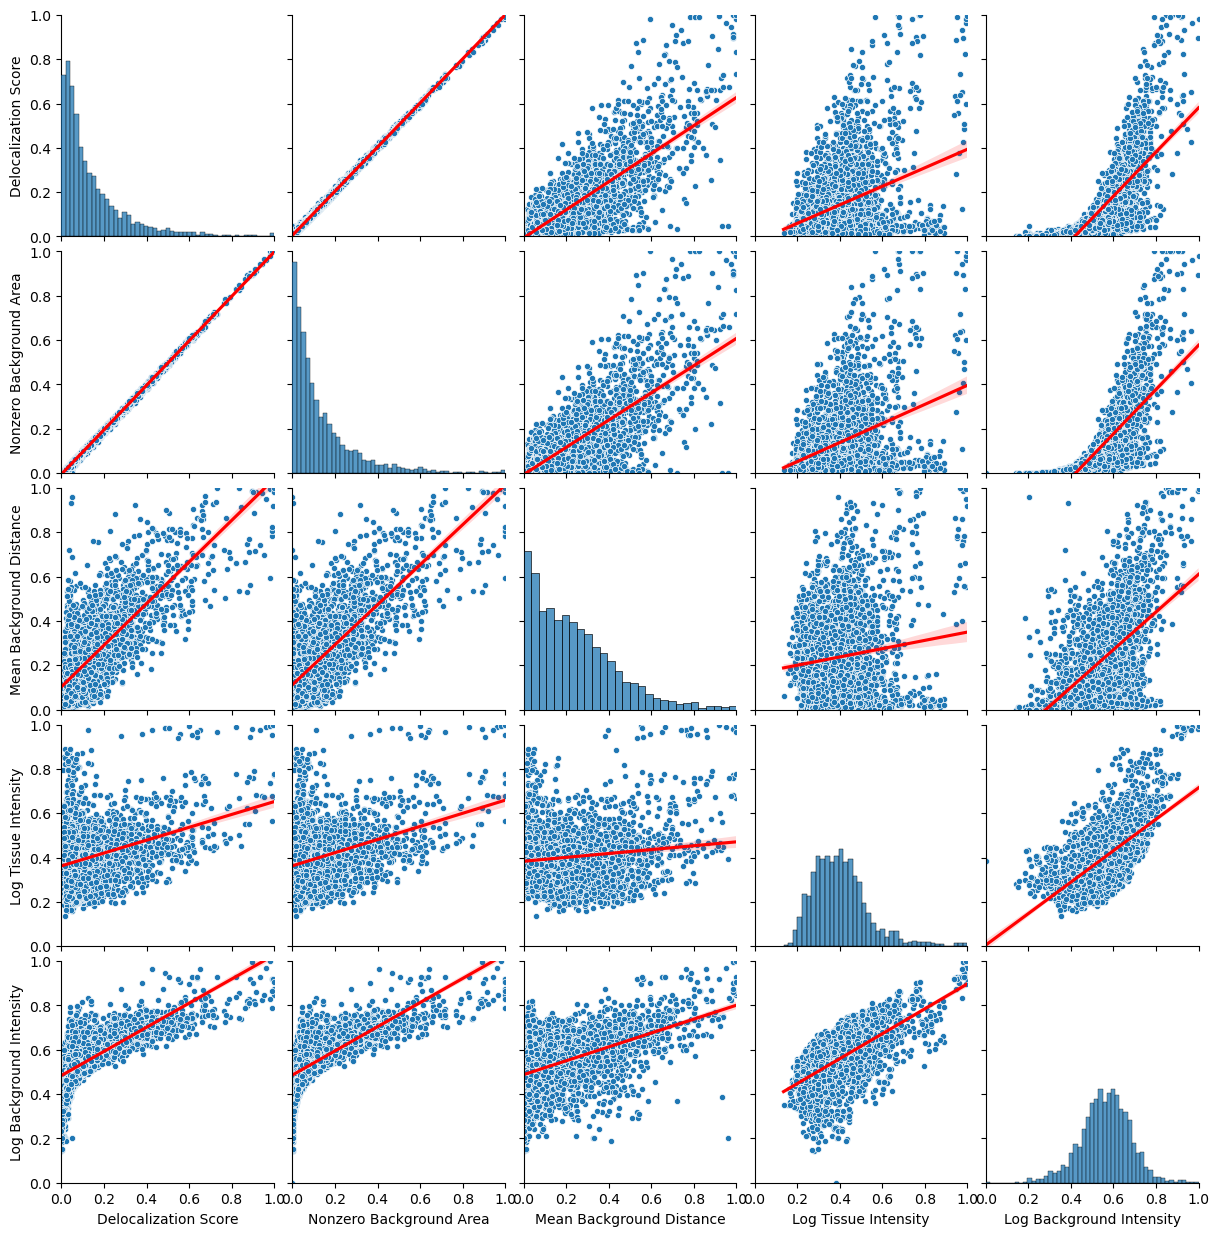

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define variable mapping: original -> display label
axis_labels = {
    'dispersion_score': 'Delocalization Score',
    'normalized_bg_nonzero_area': 'Nonzero Background Area',
    'normalized_bg_dist_mean': 'Mean Background Distance',
    'normalized_mean_intensity_tissue_log': 'Log Tissue Intensity',
    'normalized_mean_intensity_bg_log': 'Log Background Intensity'
}

# Rename columns temporarily for display
df_display = df_filtered.rename(columns=axis_labels)

# Create the pairplot without automatic diagonal plots
g = sns.pairplot(
    df_display,
    vars=list(axis_labels.values()),
    kind='reg',
    diag_kind='hist',  # <-- prevents default histograms
    plot_kws={
        'line_kws': {'color': 'red'},
        'scatter_kws': {
            's': 20,
            'alpha': 1,
            'edgecolors': 'white',
            'linewidths': 0.5
        }
    }
)


# Set all axes to range [0, 1]
for i in range(len(axis_labels)):
    for j in range(len(axis_labels)):
        ax = g.axes[i, j]
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

# Save as SVG
g.savefig("/paiplot.svg", format="svg")
plt.show()

In [24]:
df_filtered

,mz,dispersion_score,bg_nonzero_area,normalized_bg_nonzero_area,bg_dist_mean,normalized_bg_dist_mean,mean_intensity_tissue,mean_intensity_bg,normalized_mean_intensity_tissue,normalized_mean_intensity_bg,...,AAD_3,AAD_4,AAD_5,AAD_6,mean_intensity_tissue_log,mean_intensity_bg_log,normalized_mean_intensity_tissue_log,normalized_mean_intensity_bg_log,group_id,n_samples
120,201.93,0.116344,342,0.113358,2.919943,0.173078,0.001736,0.000047,0.027373,0.003222,...,0,0,0,0,-6.356157,-9.963896,0.443111,0.595790,19,1
121,201.93,0.081365,459,0.072397,4.688044,0.251758,0.001538,0.000039,0.024060,0.002663,...,0,0,0,0,-6.476944,-10.154412,0.424099,0.582368,19,1
122,201.93,0.144763,811,0.139993,4.811063,0.235393,0.001321,0.000075,0.020410,0.005133,...,0,0,0,0,-6.629463,-9.498418,0.400094,0.628583,19,1
123,201.93,0.069008,250,0.065916,2.421833,0.127747,0.001582,0.000024,0.024791,0.001642,...,0,0,0,0,-6.448992,-10.637916,0.428499,0.548304,19,1
124,201.93,0.168487,827,0.166398,4.383444,0.208177,0.001378,0.000095,0.021367,0.006493,...,0,0,0,0,-6.587176,-9.263425,0.406750,0.645139,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7675,974.55,0.047360,122,0.046025,1.788514,0.072730,0.000681,0.000006,0.009681,0.000392,...,0,0,0,0,-7.291657,-12.070068,0.295869,0.447408,649,1
7676,974.56,0.063489,666,0.063583,2.029106,0.061703,0.000796,0.000038,0.011608,0.002585,...,1,0,0,0,-7.135812,-10.184347,0.320398,0.580259,649,1
7677,974.56,0.304559,2156,0.292332,8.728052,0.536884,0.000725,0.000083,0.010419,0.005696,...,0,0,0,1,-7.229068,-9.394337,0.305720,0.635916,649,1
7678,974.56,0.214908,1297,0.208862,5.379170,0.329780,0.000806,0.000072,0.011777,0.004946,...,0,1,0,0,-7.123268,-9.535460,0.322372,0.625974,649,1


In [ ]:

# Define your sample columns
sample_cols = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
               'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
               'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
               'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']

# Filter columns that exist in df
sample_cols = [col for col in sample_cols if col in df.columns]

# Assign group to each sample column
group_map = {}
for col in sample_cols:
    if col.startswith('YC'):
        group_map[col] = 'Young Control'
    elif col.startswith('AC'):
        group_map[col] = 'Aged Control'
    elif col.startswith('YAD'):
        group_map[col] = 'Young AD'
    elif col.startswith('AAD'):
        group_map[col] = 'Aged AD'
    else:
        group_map[col] = 'Unknown'

# Get unique groups
groups = sorted(set(group_map.values()))

In [33]:
df_present

,mz,dispersion_score,sample,present
31,136.06,0.082302,YC_1,1
34,147.12,0.148929,YC_1,1
43,152.06,0.034094,YC_1,1
49,161.13,0.312176,YC_1,1
68,175.15,0.062050,YC_1,1
...,...,...,...,...
177418,1543.16,0.089526,AAD_6,1
177430,1544.15,0.121903,AAD_6,1
177440,1545.17,0.090490,AAD_6,1
177447,1548.19,0.094625,AAD_6,1


In [34]:
def assign_group(sample):
    if sample.startswith('YC'):
        return 'Young Control'
    elif sample.startswith('AC'):
        return 'Aged Control'
    elif sample.startswith('YAD'):
        return 'Young AD'
    elif sample.startswith('AAD'):
        return 'Aged AD'
    else:
        return 'Unknown'

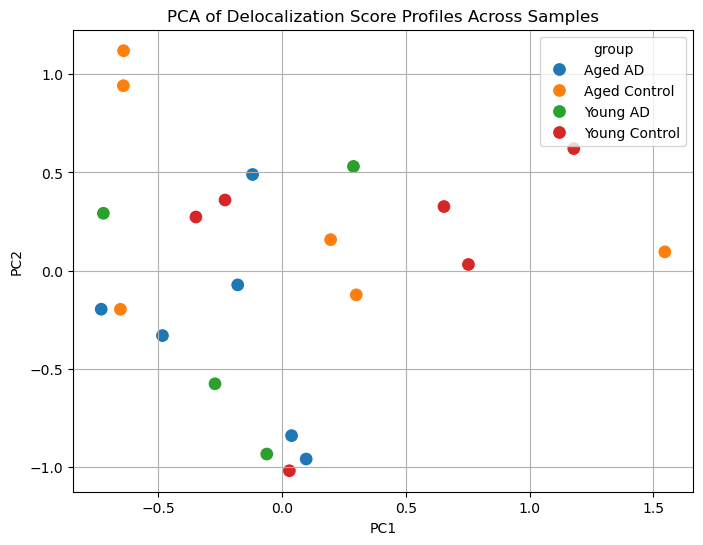

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(dispersion_by_sample_filtered.fillna(0).T)

pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'], index=dispersion_by_sample.columns)
pca_df['group'] = pca_df.index.to_series().apply(assign_group)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', s=100)
plt.title("PCA of Delocalization Score Profiles Across Samples")
plt.grid(True)
plt.savefig(f"/PCA.svg", format="svg")
plt.show()

In [37]:
def df_present_cal_group_based(df, sample_cols):
    """
    Convert a wide-format DataFrame to a long format with group assignment based on sample names.
    
    Parameters:
    - df: DataFrame containing 'mz', 'dispersion_score', and binary sample columns
    - sample_cols: List of sample column names (e.g., ['YC_1', 'AC_1', ...])

    Returns:
    - df_present: Long-format DataFrame with 'mz', 'dispersion_score', 'sample', 'present', and 'group'
    """

    # Melt to long format
    df_long = df.melt(id_vars=['mz', 'dispersion_score'], value_vars=sample_cols,
                      var_name='sample', value_name='present')

    # Keep only rows where sample is present
    df_present = df_long[df_long['present'] == 1].copy()

    # Assign group based on sample prefix
    def get_group(sample_name):
        if sample_name.startswith('YC'):
            return 'Young Control'
        elif sample_name.startswith('AC'):
            return 'Aged Control'
        elif sample_name.startswith('YAD'):
            return 'Young AD'
        elif sample_name.startswith('AAD'):
            return 'Aged AD'
        else:
            return 'Unknown'

    df_present['group'] = df_present['sample'].apply(get_group)

    return df_present

In [38]:
sample_cols = ['YC_1', 'YC_2', 'YC_3', 'YC_4', 'YC_5', 'YC_6',
               'AC_1', 'AC_2', 'AC_3', 'AC_4', 'AC_5', 'AC_6',
               'YAD_1', 'YAD_2', 'YAD_3', 'YAD_4',
               'AAD_1', 'AAD_2', 'AAD_3', 'AAD_4', 'AAD_5', 'AAD_6']
sample_cols = [col for col in sample_cols if col in df.columns] 
df_present_filtered = df_present_cal_group_based(df_filtered, sample_cols)

# Correct the sorting method and argument name
df_present_filtered.sort_values(by='mz', inplace=True)

df_present_filtered.head(40)

,mz,dispersion_score,sample,present,group
28923,201.93,0.255165,AC_4,1,Aged Control
25713,201.93,0.152896,AC_3,1,Aged Control
48198,201.93,0.069008,YAD_4,1,Young AD
35350,201.93,0.104302,AC_6,1,Aged Control
19282,201.93,0.168487,AC_1,1,Aged Control
32130,201.93,0.116344,AC_5,1,Aged Control
22493,201.93,0.144763,AC_2,1,Aged Control
38564,201.93,0.166892,YAD_1,1,Young AD
44983,201.93,0.081365,YAD_3,1,Young AD
41774,201.93,0.053880,YAD_2,1,Young AD


In [41]:
import pandas as pd
import numpy as np

def group_close_mzs(df, mz_col='mz', tolerance=0.01):
    """
    Groups rows by m/z values that are within ±tolerance and assigns the first mz as the group name.
    """
    df = df.sort_values(by=mz_col).copy()
    mz_groups = []
    current_group = []
    current_leader = None

    for mz in df[mz_col]:
        if not current_group:
            current_group = [mz]
            current_leader = mz
        elif abs(mz - current_leader) <= tolerance:
            current_group.append(mz)
        else:
            mz_groups.extend([current_leader] * len(current_group))
            current_group = [mz]
            current_leader = mz

    # Handle the final group
    if current_group:
        mz_groups.extend([current_leader] * len(current_group))

    df['mz_group'] = mz_groups
    return df

In [42]:
df_grouped_filtered = group_close_mzs(df_present_filtered, tolerance=0.02)
df_grouped_filtered[100:140]


,mz,dispersion_score,sample,present,group,mz_group
38658,264.27,0.074575,YAD_1,1,Young AD,264.27
35432,264.27,0.098900,AC_6,1,Aged Control,264.27
25799,264.27,0.072325,AC_3,1,Aged Control,264.27
16158,264.27,0.040798,YC_6,1,Young Control,264.27
57943,264.27,0.096812,AAD_3,1,Aged AD,264.27
48299,264.27,0.079579,YAD_4,1,Young AD,264.27
51496,264.27,0.134031,AAD_1,1,Aged AD,264.27
61139,264.27,0.190379,AAD_4,1,Aged AD,264.27
9740,264.27,0.071591,YC_4,1,Young Control,264.27
3309,264.27,0.066493,YC_2,1,Young Control,264.27


In [46]:
df_grouped = group_close_mzs(df_present, tolerance=0.02)
df_grouped

,mz,dispersion_score,sample,present,mz_group
121020,104.11,0.146765,YAD_4,1,104.11
88749,104.11,0.135174,AC_6,1,104.11
104886,104.11,0.107907,YAD_2,1,104.11
112955,104.11,0.271983,YAD_3,1,104.11
104888,129.14,0.160524,YAD_2,1,129.14
...,...,...,...,...,...
56471,1571.19,0.044394,AC_1,1,1571.19
96812,1571.19,0.135158,AC_6,1,1571.19
80677,1571.19,0.111163,AC_4,1,1571.19
88746,1571.19,0.136311,AC_5,1,1571.19


In [47]:
group_sizes = df_grouped['mz_group'].value_counts().sort_index()
group_sizes.head(20)

mz_group
104.11     4
129.14    13
136.06    17
147.12     5
152.06     6
161.13    21
175.12     1
175.15     3
178.06     2
179.04     2
180.07     2
184.07    22
185.07    11
192.02     3
196.88     3
198.12     3
201.16     2
201.93    22
202.18     1
203.07     1
Name: count, dtype: int64

In [50]:
df_grouped_filtered

,mz,dispersion_score,sample,present,group,mz_group
28923,201.93,0.255165,AC_4,1,Aged Control,201.93
25713,201.93,0.152896,AC_3,1,Aged Control,201.93
48198,201.93,0.069008,YAD_4,1,Young AD,201.93
35350,201.93,0.104302,AC_6,1,Aged Control,201.93
38564,201.93,0.166892,YAD_1,1,Young AD,201.93
...,...,...,...,...,...,...
3198,974.55,0.043525,YC_1,1,Young Control,974.54
67472,974.56,0.124047,AAD_5,1,Aged AD,974.54
61043,974.56,0.063489,AAD_3,1,Aged AD,974.54
70683,974.56,0.304559,AAD_6,1,Aged AD,974.54


In [51]:
def get_mz_table_by_group(df_present):
    """
    Creates a table where the row index is mz_group and each row contains
    a list of mz values belonging to that group.
    
    Parameters:
    - df_present: DataFrame with columns ['mz', 'mz_group']

    Returns:
    - DataFrame with mz_group as index and one column: list of m/z values
    """
    # Group by mz_group and collect mz values into a list
    table = df_present.groupby('mz_group')['mz'].apply(list).to_frame(name='mz_values')
    table['mz_values'] = table['mz_values'].apply(lambda lst: ', '.join(f"{x:.2f}" for x in lst))

    return table

In [52]:
table = get_mz_table_by_group(df_grouped_filtered)
"""
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
print(table)"""

"\npd.set_option('display.max_rows', None)\npd.set_option('display.max_colwidth', None)\npd.set_option('display.expand_frame_repr', False)\nprint(table)"

In [53]:
table = get_mz_table_by_group(df_grouped)
"""
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
"""
print(table)
#pd.reset_option('all')



                                                  mz_values
mz_group                                                   
104.11                       104.11, 104.11, 104.11, 104.11
129.14    129.14, 129.14, 129.14, 129.14, 129.14, 129.14...
136.06    136.06, 136.06, 136.06, 136.06, 136.06, 136.06...
147.12               147.12, 147.12, 147.12, 147.12, 147.12
152.06       152.06, 152.06, 152.06, 152.06, 152.06, 152.06
...                                                     ...
1560.15                  1560.15, 1560.15, 1560.15, 1560.15
1561.15                                             1561.15
1568.16                                             1568.16
1570.17   1570.17, 1570.17, 1570.17, 1570.17, 1570.17, 1...
1571.19   1571.19, 1571.19, 1571.19, 1571.19, 1571.19, 1...

[667 rows x 1 columns]


In [75]:
df_grouped_filtered

,mz,dispersion_score,sample,present,group,mz_group
28923,201.93,0.255165,AC_4,1,Aged Control,201.93
25713,201.93,0.152896,AC_3,1,Aged Control,201.93
48198,201.93,0.069008,YAD_4,1,Young AD,201.93
35350,201.93,0.104302,AC_6,1,Aged Control,201.93
38564,201.93,0.166892,YAD_1,1,Young AD,201.93
...,...,...,...,...,...,...
3198,974.55,0.043525,YC_1,1,Young Control,974.54
67472,974.56,0.124047,AAD_5,1,Aged AD,974.54
61043,974.56,0.063489,AAD_3,1,Aged AD,974.54
70683,974.56,0.304559,AAD_6,1,Aged AD,974.54


In [76]:
import pandas as pd

# Assuming your DataFrame is called df_present

# Step 1: Pivot the data to wide format (mz_group x sample)
df_wide = df_grouped_filtered.pivot(index='mz_group', columns='sample', values='dispersion_score')

# Optional: Drop rows with missing values (for fair comparison)
df_wide = df_wide.dropna()

# Step 2: Compute Pearson correlation among samples
pearson_corr = df_wide.corr(method='pearson')

# Step 3: Compute Spearman correlation among samples
spearman_corr = df_wide.corr(method='spearman')

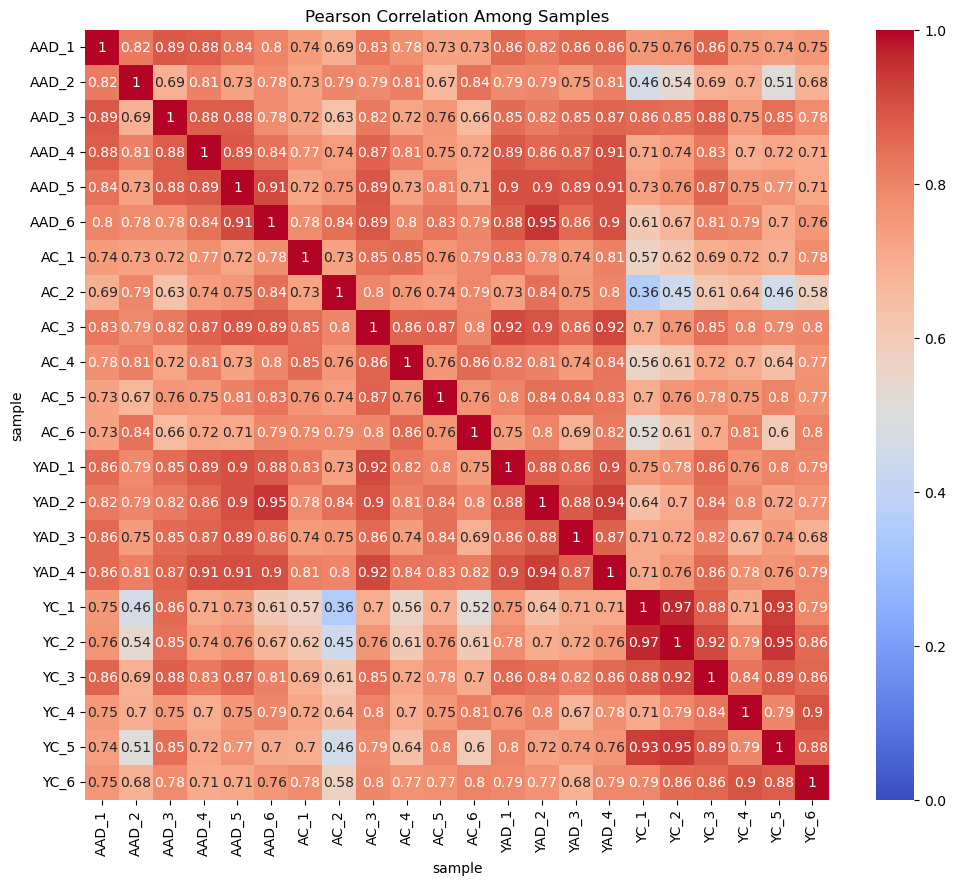

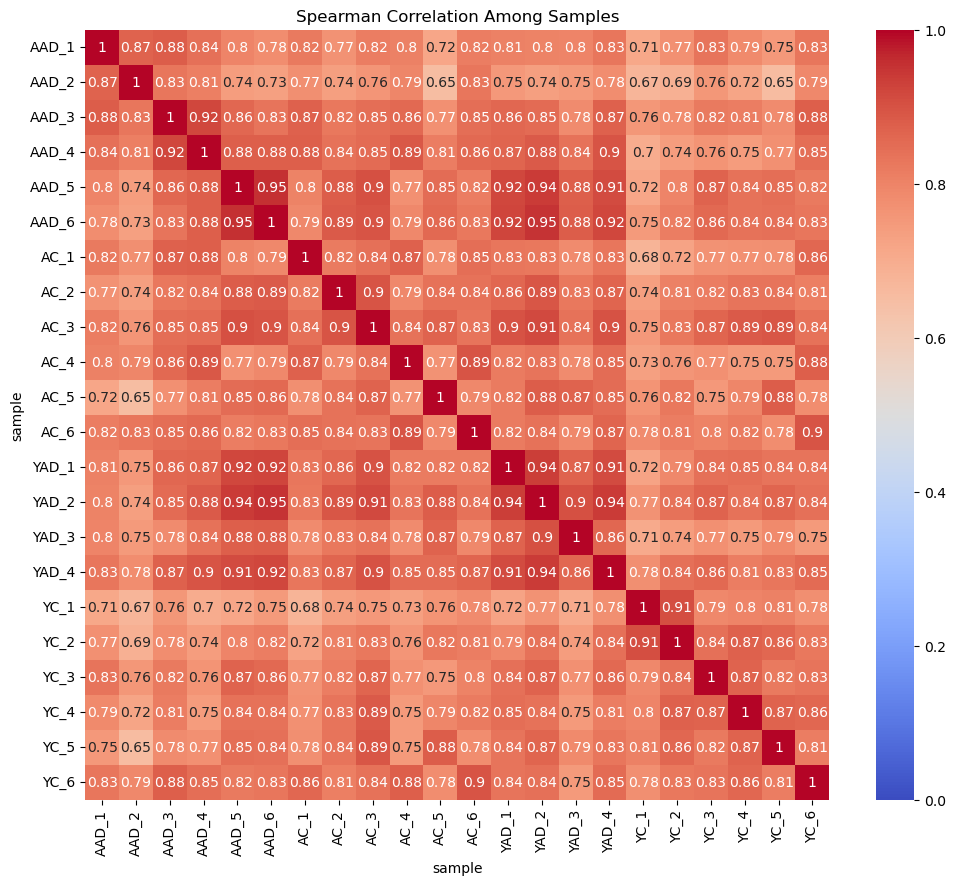

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))  # Increase the figure size as needed
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Pearson Correlation Among Samples')
plt.savefig(f"/Pearson.svg", format="svg")
plt.show()

plt.figure(figsize=(12, 10))  # Increase the figure size as needed
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Spearman Correlation Among Samples')
plt.savefig(f"/Spearman.svg", format="svg")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_dispersion_heatmap(df_wide):
    plt.figure(figsize=(14, 26))
    sns.heatmap(df_wide, cmap='viridis', annot=False, linewidths=0.5)
    plt.title('Delocalization Score Heatmap (mz_group × sample)')
    plt.xlabel('Sample')
    plt.ylabel('m/z Group')
    plt.tight_layout()
    plt.savefig(f"/Heatmap.svg", format="svg")
    plt.show()

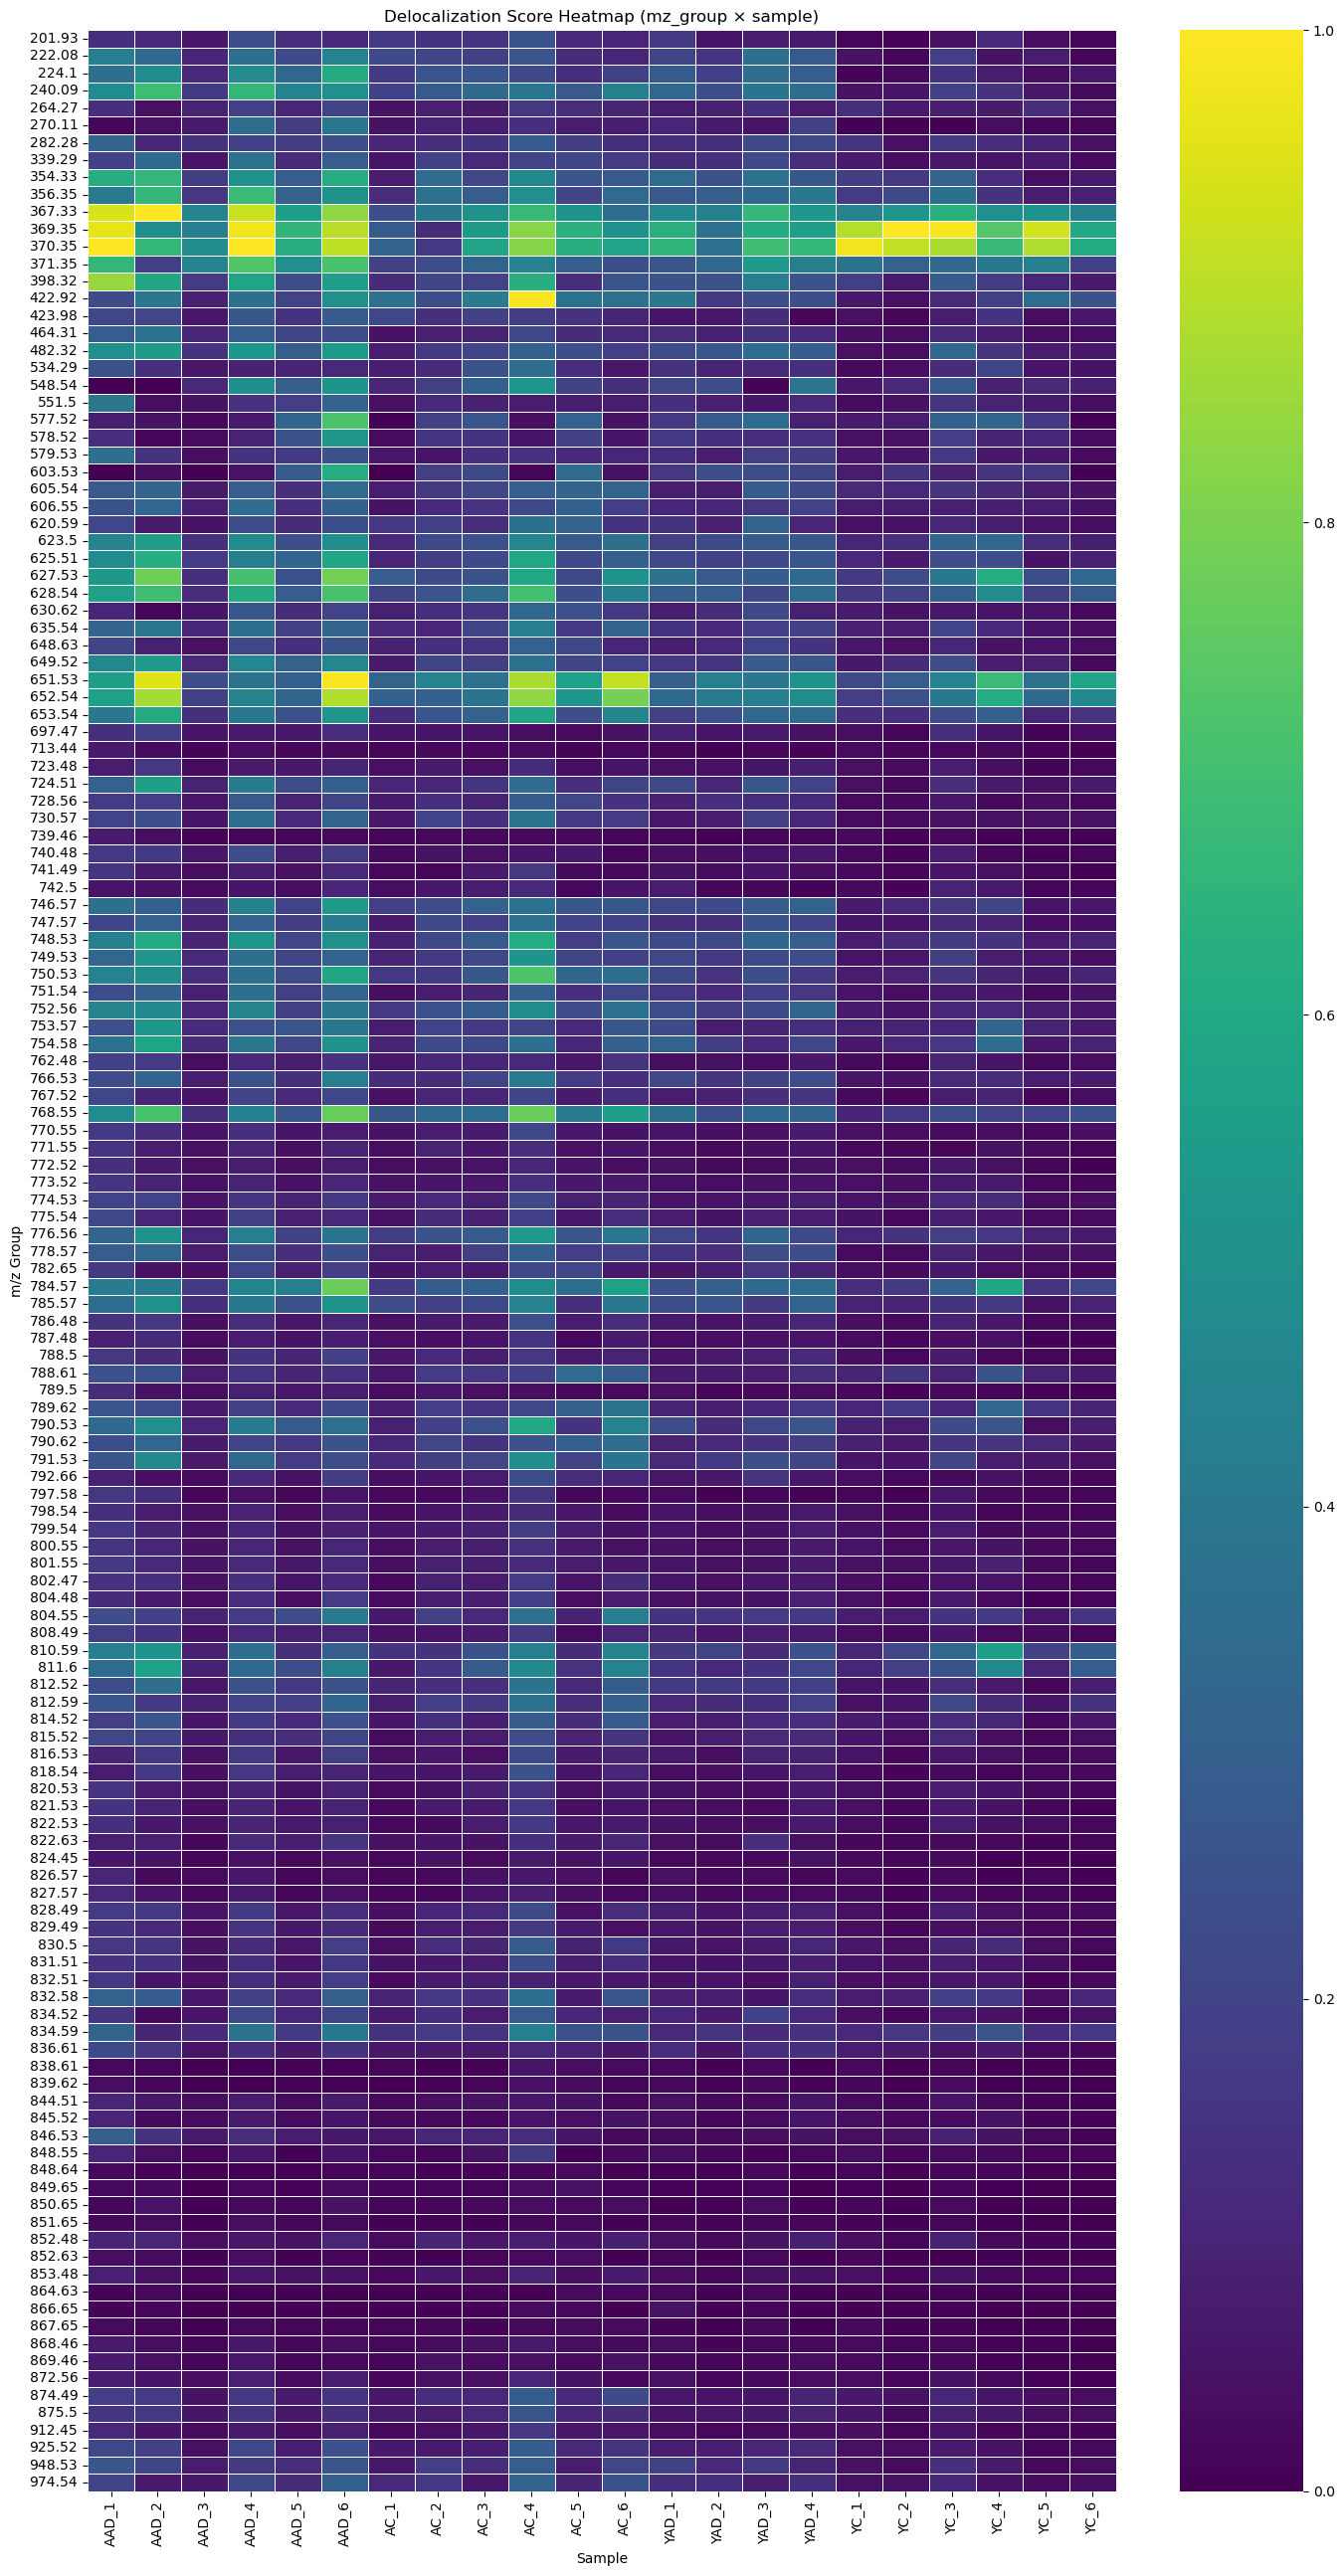

In [79]:
plot_dispersion_heatmap(df_wide)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grouped_bar_by_dispersion(df_wide, start_n=30, end_n=50):
    """
    Plots dispersion scores of m/z groups ranked by mean dispersion_score.
    Displays groups from start_n to end_n.
    """
    # Melt the DataFrame to long format
    df_long = df_wide.reset_index().melt(id_vars='mz_group', var_name='sample', value_name='dispersion_score')
    df_long['mz_str'] = df_long['mz_group'].round(2).astype(str)

    # Compute mean dispersion per mz_group and sort
    mean_dispersion = (
        df_long.groupby('mz_str')['dispersion_score']
        .mean().sort_values(ascending=False)
    )
    
    # Select m/z groups ranked start_n to end_n
    selected_mz_order = mean_dispersion.iloc[start_n:end_n].index.tolist()

    # Filter and plot
    df_plot = df_long[df_long['mz_str'].isin(selected_mz_order)].copy()

    plt.figure(figsize=(20, 8))  # a bit larger figure for readability
    sns.barplot(
        data=df_plot,
        x='mz_str',
        y='dispersion_score',
        palette='Set2',
        order=selected_mz_order,
        errorbar='se'
    )

    sns.stripplot(
        data=df_plot,
        x='mz_str',
        y='dispersion_score',
        color='red',
        alpha=0.4,
        size=4,
        jitter=0.2,
        order=selected_mz_order,
        dodge=False
    )

    # Bigger labels, ticks, and title
    plt.title(f'Delocalization Score by m/z Group (Ranks {start_n+1}–{end_n})', fontsize=32)
    plt.xlabel('m/z Group', fontsize=32)
    plt.ylabel('Delocalization Score', fontsize=32)
    plt.xticks(rotation=90, fontsize=20)  # bigger numbers on x-axis
    plt.yticks(fontsize=20)               # bigger numbers on y-axis

    plt.tight_layout()
    plt.savefig(
        f"/Delocalization_plot(Ranks {start_n+1}–{end_n}).svg", 
        format="svg"
    )
    plt.show()


/tmp/ipykernel_3320605/2872886122.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


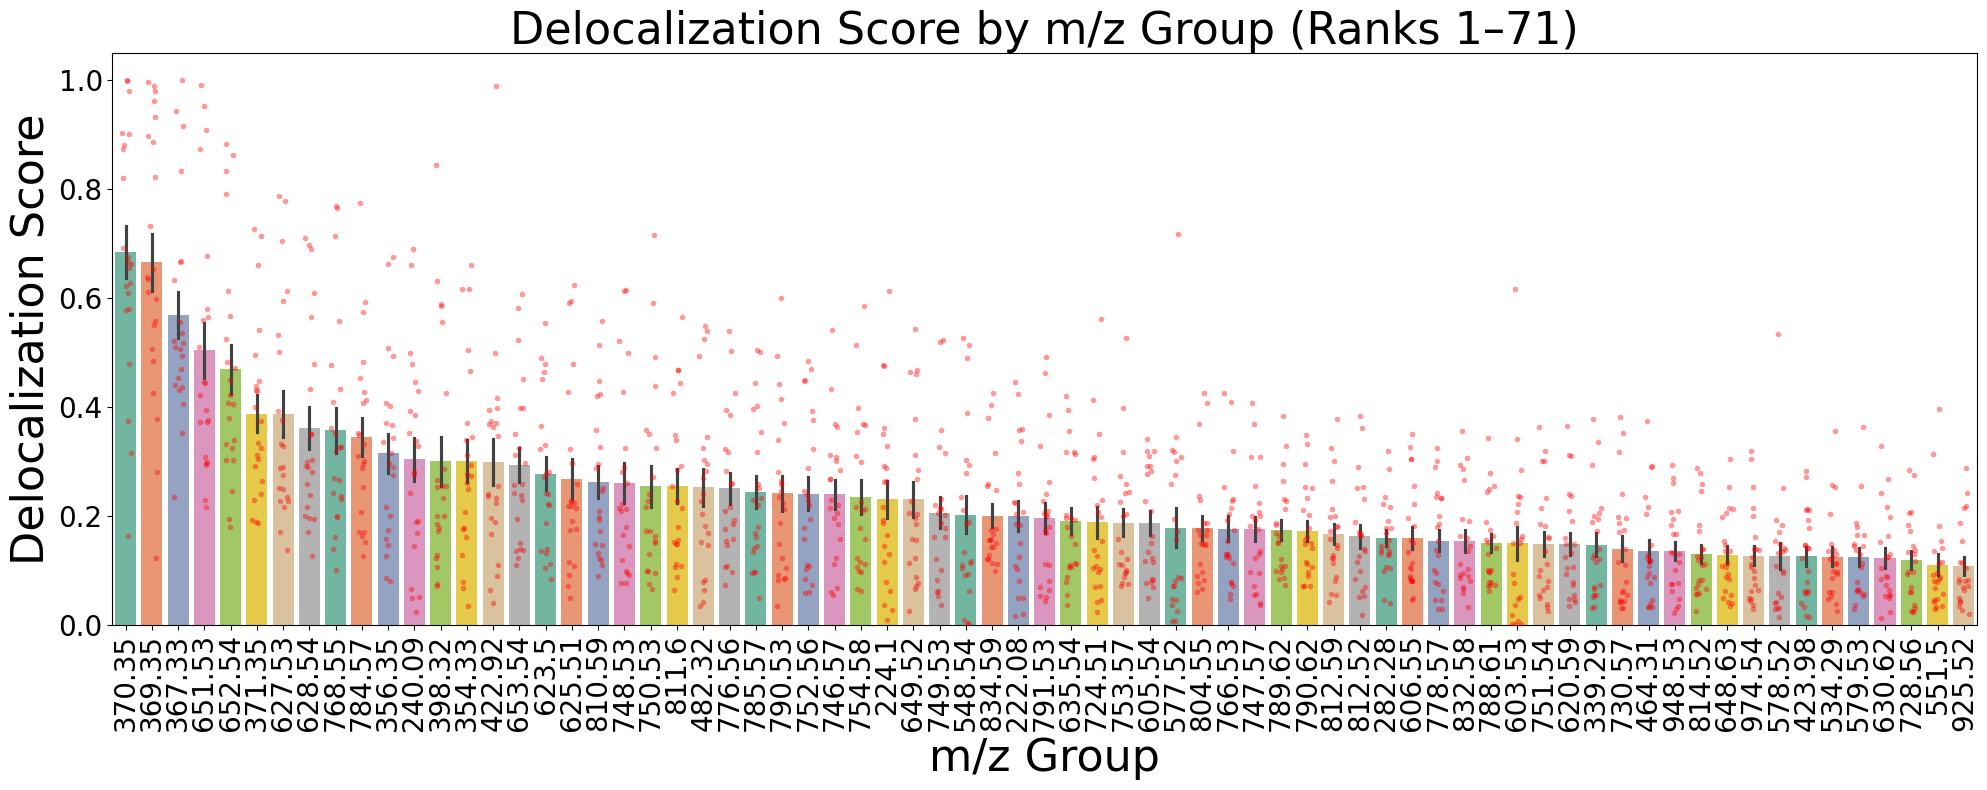

In [95]:
plot_grouped_bar_by_dispersion(df_wide, start_n=0, end_n=71)

/tmp/ipykernel_3320605/2872886122.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


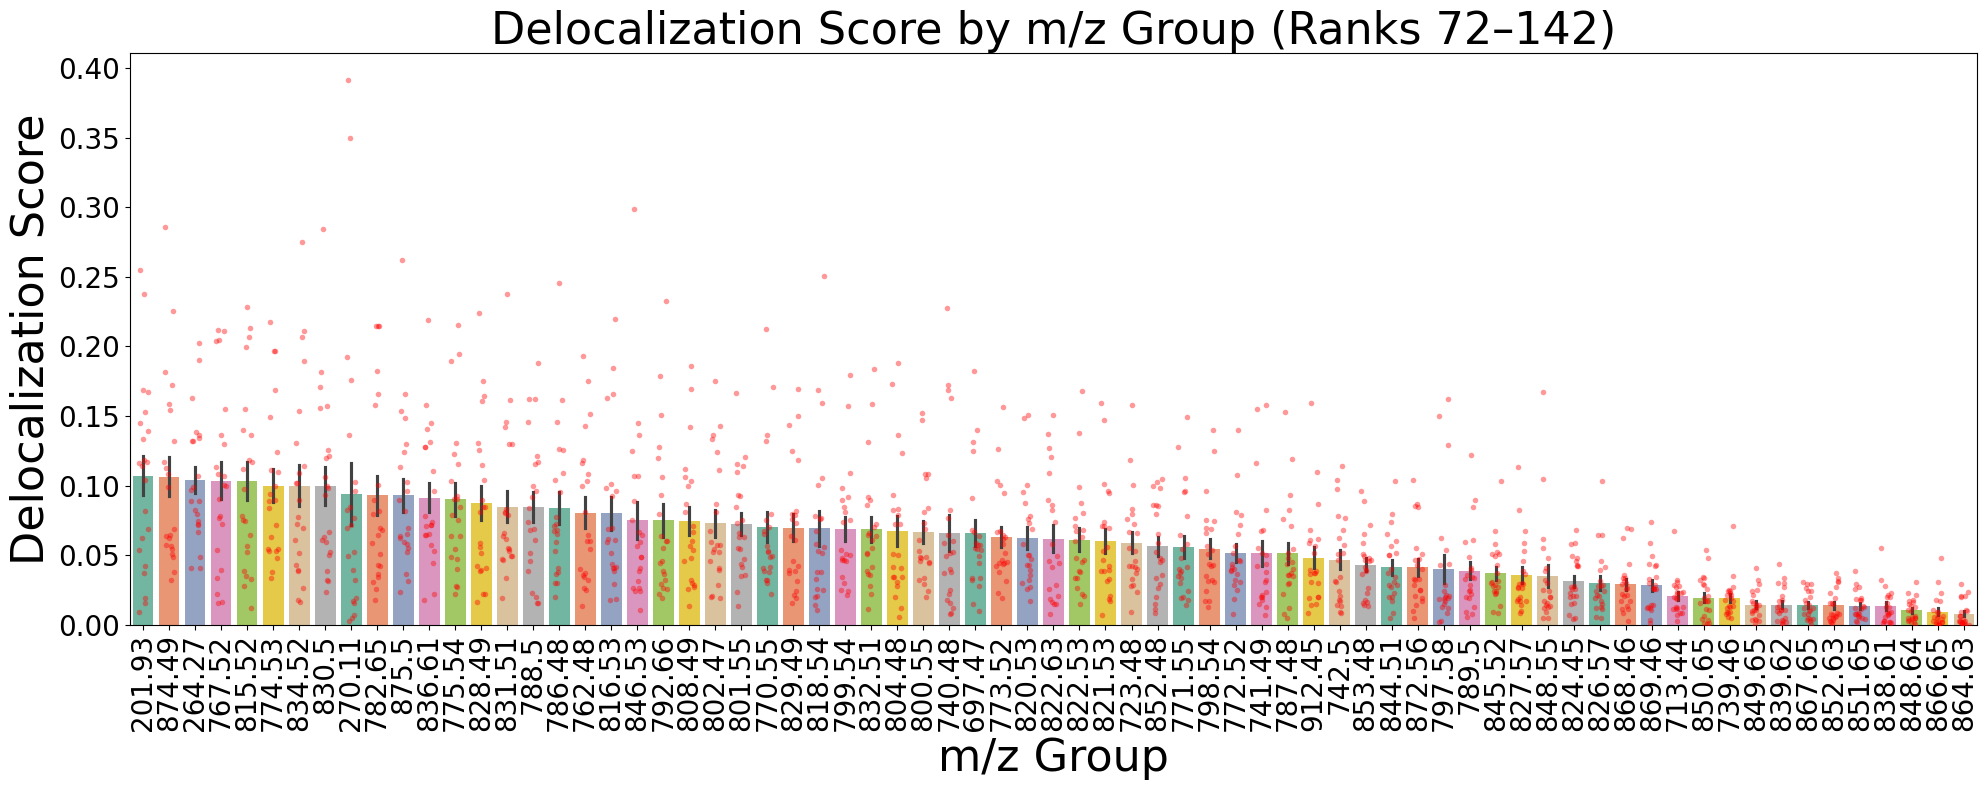

In [96]:
plot_grouped_bar_by_dispersion(df_wide, start_n=71, end_n=142)